# 06 — Analytical Views Validation

Phase 4 validation: row count parity with `raw.studies`, column coverage, list-column sanity, spot checks, and a reproduction of one Phase 3A chart using only `views.study_summary`.

**Depends on**: `run_views.py` (builds `views.study_summary`)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

conn = duckdb.connect("../data/clinical_trials.duckdb", read_only=True)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_rows", 50)

## 1. Row Count Parity

`views.study_summary` must have exactly one row per `raw.studies.nct_id`.

In [2]:
studies_n = conn.execute("SELECT COUNT(*) FROM raw.studies").fetchone()[0]
view_n = conn.execute("SELECT COUNT(*) FROM views.study_summary").fetchone()[0]
view_distinct = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM views.study_summary").fetchone()[0]
print(f"raw.studies:         {studies_n:,}")
print(f"views.study_summary: {view_n:,}  (distinct nct_id: {view_distinct:,})")
assert view_n == studies_n == view_distinct, "Row count mismatch!"

raw.studies:         119,753
views.study_summary: 119,753  (distinct nct_id: 119,753)


## 2. Coverage Summary

Should match the numbers reported by Phase 2A, 2D, and 3A.

In [3]:
conn.execute("""
    SELECT
        COUNT(*)                                                          AS studies,
        SUM(has_innovative_feature::INT)                                  AS innovative,
        SUM(has_ai_mention::INT)                                          AS ai_mention,
        SUM((therapeutic_area_count > 0)::INT)                            AS with_ta,
        SUM((mapped_drug_count > 0)::INT)                                 AS mapped_drug,
        SUM((mapped_condition_count > 0)::INT)                            AS mapped_cond,
        SUM((country_count > 0)::INT)                                     AS with_country,
        SUM((lead_sponsor_name IS NOT NULL)::INT)                         AS with_lead,
        SUM((design_architecture IS NOT NULL)::INT)                       AS with_design
    FROM views.study_summary
""").fetchdf().T.rename(columns={0: 'count'})

,count
studies,119753.0
innovative,4714.0
ai_mention,2600.0
with_ta,93606.0
mapped_drug,24528.0
mapped_cond,103609.0
with_country,106858.0
with_lead,119753.0
with_design,119734.0


## 3. Emptiness Rates by Column

For scalar columns this is the NULL rate. For LIST columns the view `COALESCE`s to `[]` and boolean flags to `FALSE`, so we treat empty lists and `FALSE` as "no data" to give a real coverage picture.

In [4]:
schema = conn.execute("PRAGMA table_info('views.study_summary')").fetchall()
n = conn.execute("SELECT COUNT(*) FROM views.study_summary").fetchone()[0]

rows = []
for _, col, dtype, *_ in schema:
    if dtype.endswith("[]"):
        kind = "list"
        empty = conn.execute(
            f'SELECT COUNT(*) FROM views.study_summary WHERE LEN("{col}") = 0'
        ).fetchone()[0]
    elif dtype == "BOOLEAN":
        kind = "bool"
        empty = conn.execute(
            f'SELECT COUNT(*) FROM views.study_summary WHERE NOT "{col}"'
        ).fetchone()[0]
    else:
        kind = "scalar"
        empty = conn.execute(
            f'SELECT COUNT(*) FROM views.study_summary WHERE "{col}" IS NULL'
        ).fetchone()[0]
    rows.append({'column': col, 'kind': kind, 'empty': empty,
                 'empty_pct': round(100 * empty / n, 2)})

pd.DataFrame(rows).sort_values('empty_pct', ascending=False).reset_index(drop=True)

,column,kind,empty,empty_pct
0,is_in_silico,bool,119752,100.00
1,is_enrichment,bool,119744,99.99
2,is_ai_augmented_design,bool,119747,99.99
3,is_digital_twin,bool,119723,99.97
4,is_n_of_1,bool,119704,99.96
...,...,...,...,...
46,therapeutic_area_count,scalar,0,0.00
47,brief_title,scalar,0,0.00
48,source,scalar,0,0.00
49,overall_status,scalar,0,0.00


## 4. Spot Checks

Pick a few NCT IDs and verify list aggregates against the source tables.

In [5]:
sample_ids = [r[0] for r in conn.execute("""
    SELECT nct_id FROM views.study_summary
    WHERE has_innovative_feature AND therapeutic_area_count >= 2 AND mapped_drug_count >= 1
    LIMIT 5
""").fetchall()]

for nct in sample_ids:
    print(f"\n=== {nct} ===")
    row = conn.execute(f"SELECT brief_title, design_architecture, primary_therapeutic_area, therapeutic_areas, innovative_feature_types, canonical_drugs, countries, lead_sponsor_name FROM views.study_summary WHERE nct_id = '{nct}'").fetchone()
    labels = ['title', 'design', 'primary_ta', 'all_tas', 'features', 'drugs', 'countries', 'lead_sponsor']
    for label, val in zip(labels, row):
        print(f"  {label}: {val}")
    # Cross-check features
    src_feats = {r[0] for r in conn.execute(f"SELECT DISTINCT feature_type FROM class.innovative_features WHERE nct_id = '{nct}'").fetchall()}
    view_feats = set(row[4])
    assert src_feats == view_feats, f"feature mismatch for {nct}: {src_feats} vs {view_feats}"
    # Cross-check TAs
    src_tas = {r[0] for r in conn.execute(f"SELECT DISTINCT therapeutic_area FROM norm.study_therapeutic_areas WHERE nct_id = '{nct}'").fetchall()}
    view_tas = set(row[3])
    assert src_tas == view_tas, f"TA mismatch for {nct}: {src_tas} vs {view_tas}"
print("\nAll spot checks passed.")


=== NCT04483960 ===
  title: Australasian COVID-19 Trial (ASCOT) ADAptive Platform Trial
  design: Factorial RCT
  primary_ta: Infectious Disease
  all_tas: ['Infectious Disease', 'Respiratory']
  features: ['platform', 'bayesian', 'adaptive']
  drugs: ['remdesivir', 'NAFAMOSTAT MESYLATE', 'Dalteparin', 'Tinzaparin', 'Enoxaparin']
  countries: ['Australia']
  lead_sponsor: University of Melbourne

=== NCT04879121 ===
  title: Larotrectinib for the Treatment of NTRK Amplification Positive, Locally Advanced or Metastatic Solid Tumors
  design: Single-Arm
  primary_ta: General/Symptoms
  all_tas: ['Oncology', 'General/Symptoms']
  features: ['basket']
  drugs: ['LAROTRECTINIB SULFATE']
  countries: ['United States']
  lead_sponsor: M.D. Anderson Cancer Center

=== NCT04862221 ===
  title: TReatment for ImmUne Mediated PathopHysiology
  design: Parallel RCT
  primary_ta: Gastroenterology
  all_tas: ['Gastroenterology', 'Neurology', 'Metabolic/Endocrine']
  features: ['adaptive']
  drugs: 

## 5. Reproduce Phase 3A Chart — Innovation Rate by Therapeutic Area

Using **only** `views.study_summary` (no joins to `class.*` or `norm.*`). If this matches notebook 04, the view is sufficient for downstream analysis.

In [6]:
df = conn.execute("""
    SELECT ta AS therapeutic_area,
           COUNT(*) AS studies,
           SUM(has_innovative_feature::INT) AS innovative,
           100.0 * SUM(has_innovative_feature::INT) / COUNT(*) AS innovation_rate
    FROM views.study_summary, UNNEST(therapeutic_areas) AS u(ta)
    GROUP BY ta
    HAVING COUNT(*) >= 500
    ORDER BY innovation_rate DESC
""").fetchdf()
df

,therapeutic_area,studies,innovative,innovation_rate
0,Behavioral/Lifestyle,8529,663.0,7.773479
1,Psychiatry,10365,657.0,6.338640
2,Infectious Disease,5947,289.0,4.859593
3,Trauma/Emergency,3967,192.0,4.839929
4,Respiratory,8954,417.0,4.657136
5,Obstetrics/Gynecology,7990,359.0,4.493116
6,Neurology,17151,754.0,4.396245
7,Urology/Nephrology,6114,268.0,4.383382
8,Metabolic/Endocrine,11612,470.0,4.047537
9,General/Symptoms,27197,1096.0,4.029856


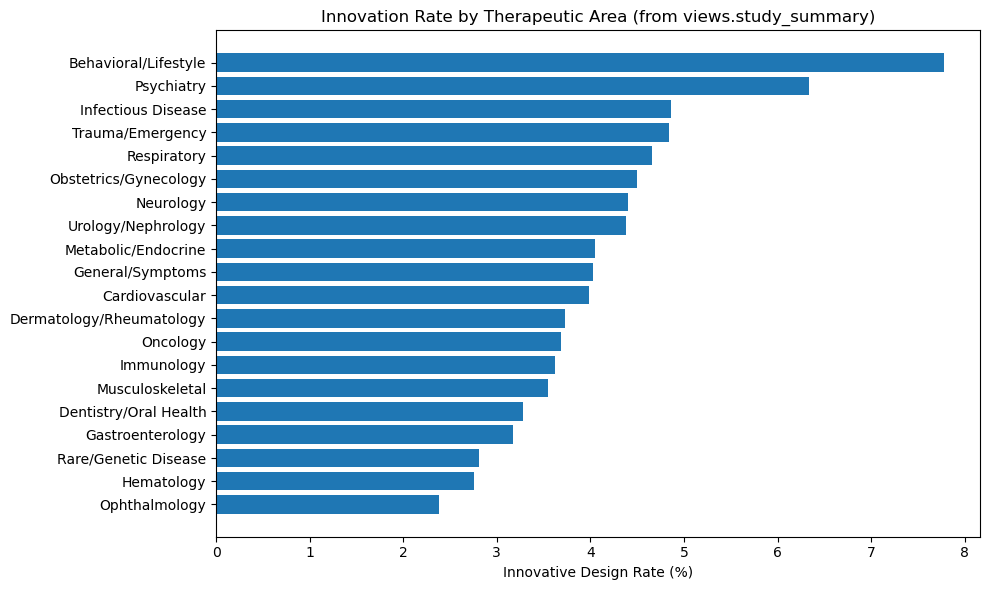

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df['therapeutic_area'], df['innovation_rate'])
ax.set_xlabel('Innovative Design Rate (%)')
ax.set_title('Innovation Rate by Therapeutic Area (from views.study_summary)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Primary TA Distribution

In [8]:
conn.execute("""
    SELECT primary_therapeutic_area, COUNT(*) AS studies
    FROM views.study_summary
    WHERE primary_therapeutic_area IS NOT NULL
    GROUP BY 1 ORDER BY studies DESC
""").fetchdf()

,primary_therapeutic_area,studies
0,General/Symptoms,16924
1,Cardiovascular,12350
2,Gastroenterology,8730
3,Behavioral/Lifestyle,8233
4,Dermatology/Rheumatology,6863
5,Oncology,6803
6,Metabolic/Endocrine,6072
7,Neurology,5165
8,Hematology,4113
9,Psychiatry,3552


In [9]:
conn.close()